# Surface Area Estimation of Tree Bark
This notebook will showcase a method for calculating the surface area of the bark of a tree trunk from a µCT-scan.
Primarily, the `qim3d` library will be showcased and used.


First, the necessary libraries are imported:

In [1]:
import qim3d
from pygel3d import hmesh

## 1. 📂 Loading the data
The `qim3d` library's `io.Downloader()` is used to load in the trunk volumetric data from the QIM data repository:

In [ ]:
downloader = qim3d.io.Downloader()
data = downloader.Oak_Branch.Oak_branch(load_file=True)

The volume is converted to the OME-Zarr format to enable faster, more memory-efficient analysis by working with a chunked, multiscale version of the volume that is optimized for on-demand access. The `qim3d` library's `io.export_ome_zarr()` converts the volume to this format and exports it:

In [ ]:
qim3d.io.export_ome_zarr("Trunk.zarr", data, chunk_size=100, downsample_rate=2, replace=True)

Now, the OME-Zarr volume is loaded in:

In [4]:
volume = qim3d.io.import_ome_zarr("Trunk.zarr", scale=2, load=True)

Data contains 5 scales:
- Scale 0: (1000, 800, 800)
- Scale 1: (500, 400, 400)
- Scale 2: (250, 200, 200)
- Scale 3: (125, 100, 100)
- Scale 4: (62, 50, 50)

Loading scale 2 with shape (250, 200, 200)


## 2. 🔍 Exploring the data

The tree trunk can now be visualized using `qim3d`'s `viz.volumetric()`. The minimum and maximum intensities have been adjusted interactively in the rendering until the result was visually pleasing, after which the values were passed into the function. A list of available colormaps can be found at the __[matplotlib docs](https://matplotlib.org/stable/users/explain/colors/colormaps.html)__. The resulting visualziation can be seen below:

In [ ]:
qim3d.viz.volumetric(volume, vmin=5, vmax=10, color_map='Oranges')

<img src="./screenshots/trunk_visualization.gif" alt="Trunk Visualized" width="800">

Slices along the three axes can also be inspected using `qim3d`'s `viz.slicer_orthogonal()`:

In [ ]:
qim3d.viz.slicer_orthogonal(volume, color_map='Oranges')

<img src="./screenshots/trunk_slicer_orthogonal.png" alt="Trunk Orthogonal" width="900">

It can be seen that the trunk is pretty well-defined, meaning it should be possible to segment out the trunk nicely from the background air. This is further evident, when `qim3d`'s `viz.histogram()` is used for visualizing the histogram of the volume:

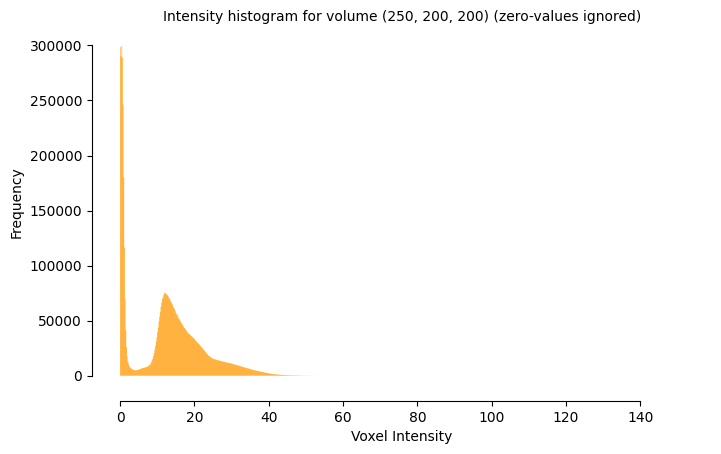

<Axes: title={'center': 'Intensity histogram for volume (250, 200, 200) (zero-values ignored)'}, xlabel='Voxel Intensity', ylabel='Frequency'>

In [7]:
qim3d.viz.histogram(volume)

It is seen that the histogram follows a bimodal distribution, with a sharp valley between the two peaks, indicating trunk and air.

## 3. 🧼 Preprocessing and Filtering

Before attempting to segment the volume intro trunk and air, the volume is smoothed slightly, using a gaussian filter, in order to remove noise:

In [8]:
vol_smoothed = qim3d.filters.gaussian(volume, sigma=2)

To find a suiting threshold value, `qim3d`'s `viz.threshold()` is used. It is interactive, allowing the user to see the result of standard thresholding techniques, but also allowing the user to manually choose a thresholding value:

In [ ]:
qim3d.viz.threshold(vol_smoothed, cmap_image='Oranges')

<img src="./screenshots/trunk_threshold.png" alt="Trunk Threshold" width="1000">

After exploring the options, the threshold of voxel intensity 4 - found using Otsu's method - looked to correctly segment out the trunk. Especially the ends needed to be looked at. This threshold is now applied to the smoothed volume to create a binary volume:

In [9]:
vol_bin = vol_smoothed > 4

A total of 10 slices of this binary volume are now visualized to check that the segmentation looks right. This is done using `qim3d`'s `viz.slices_grid()`:

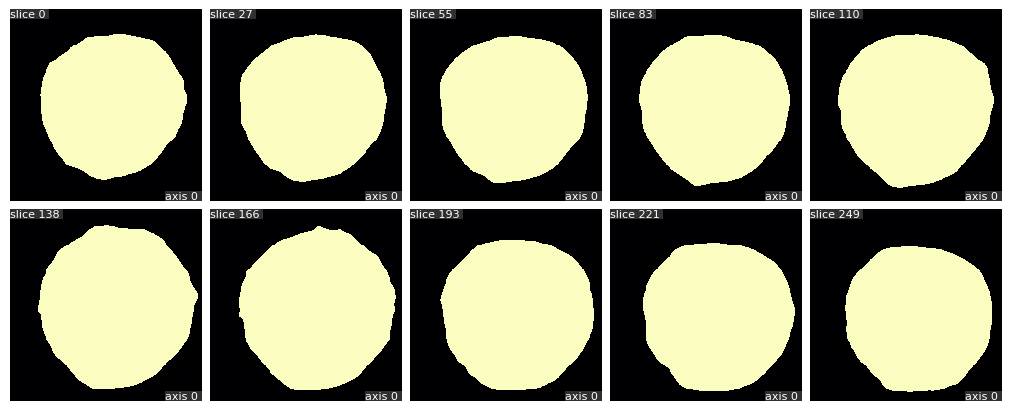

In [10]:
qim3d.viz.slices_grid(vol_bin, num_slices=10)

The segmentation does indeed look correct.

## 4. 🕸️ Surface Mesh Generation

Now, a mesh making up the surface of this binary structure is to be created using `qim3d`'s `mesh.from_volume()`. However, the current volume will create a mesh that has too many faces and vertices to be rendered smoothly. Therefore, we use the argument 'mesh_precision=0.5' to reduce the mesh resolution.

In [48]:
factor = 0.5
mesh = qim3d.mesh.from_volume(vol_bin, mesh_precision=factor)

The area of this mesh should correspond to that of the outer surface of the tree trunk. The area of a mesh can be calculated using `qim3d`'s `features.area()`:

In [49]:
area = qim3d.features.area(mesh)
print(f"Area of mesh: {area}")

Area of mesh: 43675.96935357305


Note however, that this area is in voxel coordintes, and that these also have been altered due to the 'mesh_precision=0.5'. It will be transformed into world coordinates after a quick visualization of the mesh using `qim3d`'s `viz.mesh()`:

In [ ]:
qim3d.viz.mesh(mesh)

<img src="./screenshots/trunk_mesh.gif" alt="Trunk Mesh" width="600">

If the volume resolution is isotropic, meaning the voxel resolution is identical along all axes, the area can easily be converted into mm². Given a resolution in $\frac{\text{mm}}{\text{voxel}}$, the area in mm² is calculated in the following way:

In [ ]:
resolution = 0.0286 # Enter your value (mm/voxel)
resolution *= 1/factor # Adjust for downsampling by 'factor' in mesh generation
scaling_factor = resolution ** 2 
area_world = area * scaling_factor
print(f"Total bark area: {area_world} mm²")

Total bark area: 142.90078356979444 mm²


The resolution of volumes from the QIM Data Repository can be found at __[data.qim.dk](https://data.qim.dk)__. For the oak branch specifically, it can be found __[here](https://data.qim.dk/pages/oak_branch.html)__.